# Regresión Lineal con Redes Neuronales
**Dataset:** California Housing

En este notebook voy a usar una red neuronal para hacer regresión lineal. La idea que tengo es predecir el precio de casas en California usando datos como el ingreso de la zona, cuántos cuartos tienen las casas, etc.

Aparte voy a mostrar qué pasa cuando el modelo aprende muy poco (underfitting) y que pasa cuando aprende demasiado (overfitting).

---
## 1 - Preparacion de los datos

In [1]:
# Importamos todas las librerias y dependencias necesarias 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

# Esto es para que los resultados sean iguales cada vez que corro el notebook
np.random.seed(42)
tf.random.set_seed(42)



I0000 00:00:1776021937.309596    1923 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776021955.713105    1923 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776021965.421105    1923 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Importo el dataset de california housing que viene incluido en sklearn
datos = fetch_california_housing()

X = datos.data    # las variables de entrada (ingreso, habitaciones, etc)
y = datos.target  # lo que quiero predecir (precio de la casa)

print("forma de X:", X.shape)
print("forma de y:", y.shape)
print("\nColumnas:", datos.feature_names)
print("\nprimeros 5 valores del precio:", y[:5])

forma de X: (20640, 8)
forma de y: (20640,)

Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

primeros 5 valores del precio: [4.526 3.585 3.521 3.413 3.422]


---
El dataset tiene 20,640 casas con 8 características cada una. El precio está en cientos de miles de dólares.

Las 8 características son:
- MedInc: ingreso mediano de la zona
- HouseAge: edad de las casas
- AveRooms: promedio de habitaciones
- AveBedrms: promedio de dormitorios
- Population: población del bloque
- AveOccup: promedio de ocupantes
- Latitude y Longitude: ubicación geográfica

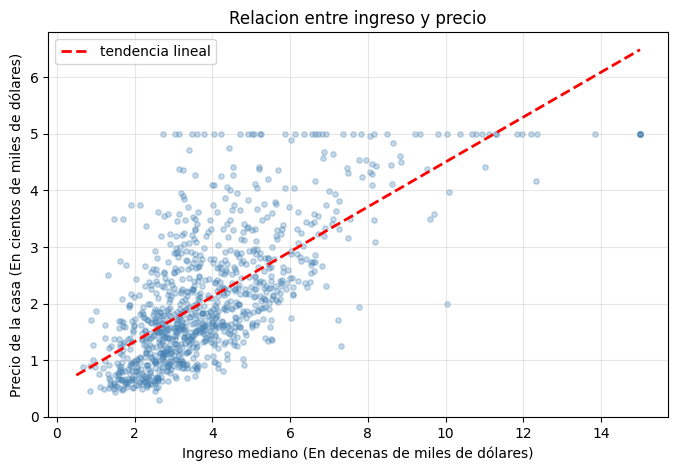

la linea roja muestra la tendencia lineal positiva entre ingreso y precio


In [3]:
muestra = np.random.choice(len(X), 1000, replace=False)

plt.figure(figsize=(8, 5))
plt.scatter(X[muestra, 0], y[muestra], alpha=0.3, color='steelblue', s=15)

# Linea de tendencia
m, b = np.polyfit(X[muestra, 0], y[muestra], 1)
x_linea = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
plt.plot(x_linea, m * x_linea + b, color='red', linewidth=2, 
         linestyle='--', label='tendencia lineal')

plt.xlabel('Ingreso mediano (En decenas de miles de dólares)')
plt.ylabel('Precio de la casa (En cientos de miles de dólares)')
plt.title('Relacion entre ingreso y precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("la linea roja muestra la tendencia lineal positiva entre ingreso y precio")

In [4]:
# Division en entrenamiento y prueba (80% para entrenar, 20% para probar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizo los datos para que la red neuronal aprenda mejor
# esto hace que todos los valores tengan media 0 y desviacion 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("datos de entrenamiento:", X_train.shape)
print("datos de prueba:", X_test.shape)

datos de entrenamiento: (16512, 8)
datos de prueba: (4128, 8)


---
## 2 - Modelo bien entrenado

Primero la construccion de la red neuronal. La arquitectura es simple: unas capas ocultas y una capa de salida con 1 neurona (sin función de activación) porque es regresión, no clasificación.

Esta misma arquitectura la voy a usar en los 3 modelos, lo único que cambia es con cuántas épocas la entreno.

In [5]:
# Funcion para construir el modelo, asi evito repetir el codigo a lo largo del proceso de entrenamiento
def crear_modelo():
    modelo = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(8,)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)  
    ])

    modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return modelo

# muestro como se ve el modelo
modelo_prueba = crear_modelo()
modelo_prueba.summary()

/home/codespace/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776021967.427726    1923 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Modelo bien entrenado con 100 epocas
# 100 epocas es suficiente para que aprenda sin memorizar
modelo_bueno = crear_modelo()

historia_bueno = modelo_bueno.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100


516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.8875 - mae: 0.6312 - val_loss: 0.4397 - val_mae: 0.4710
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3915 - mae: 0.4448 - val_loss: 0.3806 - val_mae: 0.4447
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3556 - mae: 0.4220 - val_loss: 0.3569 - val_mae: 0.4266
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3375 - mae: 0.4079 - val_loss: 0.3458 - val_mae: 0.4112
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3239 - mae: 0.3972 - val_loss: 0.3358 - val_mae: 0.4031
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3174 - mae: 0.3914 - val_loss: 0.3237 - val_mae: 0.3944
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3089 - mae: 0.3853 - val_loss: 0.3179 - val_mae: 0.3893
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3029 - mae: 0.3809 - val_loss: 0.3111 - val_mae: 0.3846
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss:

In [7]:
# Prueba del modelo bien entrenado
predicciones_bueno = modelo_bueno.predict(X_test).flatten()

mse_bueno = mean_squared_error(y_test, predicciones_bueno)
r2_bueno = r2_score(y_test, predicciones_bueno)

print("Resultados del modelo bien entrenado:")
print(f"  MSE: {mse_bueno:.4f}")
print(f"  R2:  {r2_bueno:.4f}")
print(f"\nEl modelo explica el {r2_bueno*100:.1f}% de la variabilidad del precio")

 73/129 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step
Resultados del modelo bien entrenado:
  MSE: 0.2759
  R2:  0.7894

El modelo explica el 78.9% de la variabilidad del precio


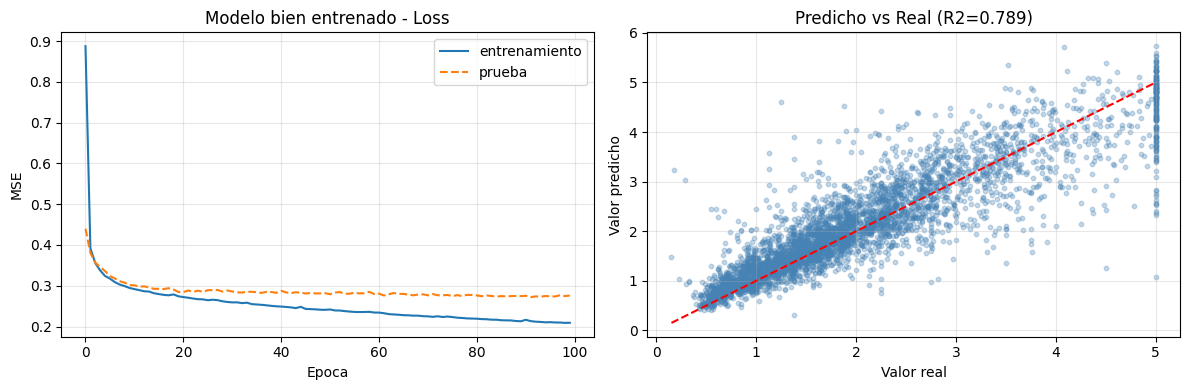

Las dos curvas bajan juntas y se estabilizan, una señal de que el modelo está bien entrenado y no memoriza


In [8]:
# Graficas de las curvas de aprendizaje
# Si el modelo está bien entrenado, las dos curvas bajaran juntas y estabilizarse
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia_bueno.history['loss'], label='entrenamiento')
plt.plot(historia_bueno.history['val_loss'], label='prueba', linestyle='--')
plt.title('Modelo bien entrenado - Loss') #Curva de perdida (MSE) durante el entrenamiento
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_bueno, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Predicho vs Real (R2={r2_bueno:.3f})') #Variabilidad en el precio de las casas.
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Las dos curvas bajan juntas y se estabilizan, una señal de que el modelo está bien entrenado y no memoriza")

---
## 3 - Modelo subentrenado (Underfitting)

Ahora voy a entrenar el mismo modelo pero con muy pocas épocas (solo 5). El modelo no va a tener suficiente tiempo para aprender y va a quedar con un error alto tanto en entrenamiento como en prueba.

Basicamente eso es underfitting: El modelo es demasiado "flojo" para aprender los patrones y dar un buen resultado.

In [9]:
# Modelo subentrenado: misma arquitectura pero solo 5 epocas
modelo_under = crear_modelo()

historia_under = modelo_under.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\ncon solo 5 epocas el modelo no alcanza a aprender bien")

Epoch 1/5


/home/codespace/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2318 - mae: 0.7499 - val_loss: 0.4404 - val_mae: 0.4730
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3994 - mae: 0.4510 - val_loss: 0.3905 - val_mae: 0.4483
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3677 - mae: 0.4310 - val_loss: 0.3654 - val_mae: 0.4292
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3478 - mae: 0.4166 - val_loss: 0.3484 - val_mae: 0.4157
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3328 - mae: 0.4035 - val_loss: 0.3359 - val_mae: 0.4027

con solo 5 epocas el modelo no alcanza a aprender bien


In [10]:
# evaluo el modelo subentrenado
predicciones_under = modelo_under.predict(X_test).flatten()

mse_under = mean_squared_error(y_test, predicciones_under)
r2_under = r2_score(y_test, predicciones_under)

print("Resultados del modelo subentrenado:")
print(f"  MSE: {mse_under:.4f}  <-- mucho mas alto que el modelo bueno")
print(f"  R2:  {r2_under:.4f}   <-- mucho mas bajo")
print(f"\nComparacion:")
print(f"  MSE bueno: {mse_bueno:.4f} vs MSE subentrenado: {mse_under:.4f}")
print(f"  R2 bueno:  {r2_bueno:.4f} vs R2 subentrenado:  {r2_under:.4f}")

 67/129 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step
Resultados del modelo subentrenado:
  MSE: 0.3359  <-- mucho mas alto que el modelo bueno
  R2:  0.7437   <-- mucho mas bajo

Comparacion:
  MSE bueno: 0.2759 vs MSE subentrenado: 0.3359
  R2 bueno:  0.7894 vs R2 subentrenado:  0.7437


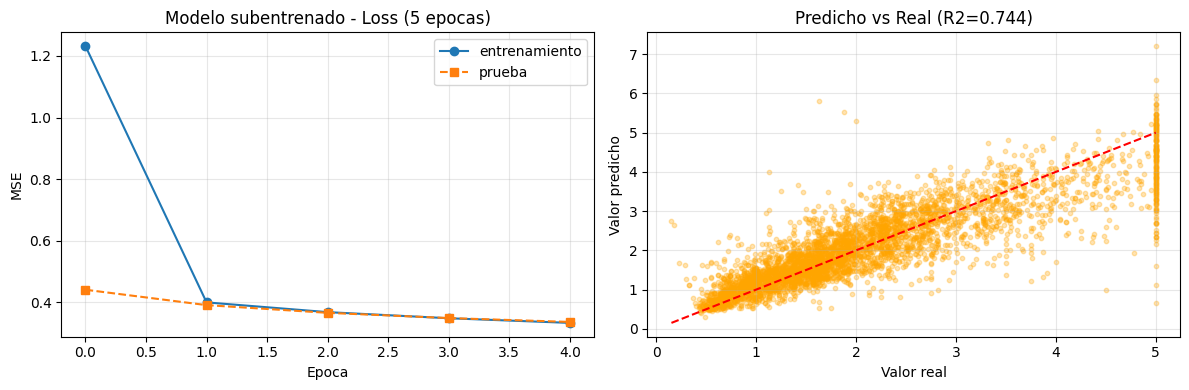

La curva sigue bajando al final, es por la carencia de  epocas
Los puntos naranjas comparados con los azules del commit 2, estan mas dispersos al rededor de la linea roja, especialmente en valores altos. Lo que muestra que el modelo subentrenado no logra predecir bien los precios


In [11]:
# grafico las curvas del modelo subentrenado
# la señal de underfitting es que la curva todavia esta bajando cuando se detiene
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia_under.history['loss'], label='entrenamiento', marker='o')
plt.plot(historia_under.history['val_loss'], label='prueba', linestyle='--', marker='s')
plt.title('Modelo subentrenado - Loss (5 epocas)')
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_under, alpha=0.3, s=10, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Predicho vs Real (R2={r2_under:.3f})')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("La curva sigue bajando al final, es por la carencia de  epocas")
print("Los puntos naranjas comparados con los azules del commit 2, estan mas dispersos al rededor de la linea roja, especialmente en valores altos. Lo que muestra que el modelo subentrenado no logra predecir bien los precios")